<a href="https://colab.research.google.com/github/Juanezm/ml-model-battery-levels-iot/blob/main/scenario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Escenario 1**: Conjuntos de datos de entrenamiento y prueba separados  
#### En este primer escenario, el modelo se entrena utilizando el conjunto de datos 1, reservando el 20% de los datos para validación. 
#### La prueba se realiza utilizando el conjunto de datos 0. 
#### Este método evalúa la capacidad del modelo cuando es entrenado y probado en diferentes conjuntos de datos.

In [1]:
# Cuarto
id_train = "380033001951343334363036"
id_test = "46005a000351353337353037" 

In [2]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Bidirectional, TimeDistributed, Conv1D, Flatten, MaxPooling1D, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA

from IPython.display import clear_output
from IPython.display import HTML
#import imgkit

2024-12-02 21:19:26.803662: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Variables a definir

In [3]:
n_components = 5
batch_size = 72

In [4]:
seq_length = 72
forecast_steps = seq_length 
future_steps = 1
intervalo = "15min"

In [5]:
quitar = ["soil_humidity"]
re_sample = "1H"
cut_train = 0
cut_test = 0

#### Función para normalizar los datos

In [6]:
def normalise_data(scaler_x, x, scaler_y, y):# Utiliza MinMaxScaler
    X_train = pd.DataFrame(scaler_x.fit_transform(x))
    y_train = pd.DataFrame(scaler_y.fit_transform(y.values.reshape(-1, 1)))
    return X_train, y_train

####  La función create_sequences toma dos conjuntos de datos, X e y, y un parámetro seq_length que define la longitud de cada secuencia de entrada que se va a crear. Su objetivo es estructurar los datos en secuencias de longitud fija, lo cual es muy útil en modelos que procesan secuencias, como los modelos de series temporales o redes neuronales recurrentes (RNNs).

#### El bucle for recorre los datos hasta len(X) - seq_length para garantizar que se pueden crear secuencias completas de longitud seq_length.
#### En cada iteración:
#### X[i:(i+seq_length)]: Extrae una secuencia de longitud seq_length de X, que va desde el índice i hasta i+seq_length (sin incluir i+seq_length). Esta secuencia se agrega a xs.
#### y[i+seq_length]: Obtiene el valor objetivo en el índice i + seq_length y lo agrega a ys. Esto representa el valor que queremos predecir después de observar la secuencia anterior.

In [7]:
def create_sequences(X, y, seq_length):
    xs = []
    ys = []

    for i in range(len(X)-seq_length):
        xs.append(X[i:(i+seq_length)])
        ys.append(y[i+seq_length])

    return np.array(xs), np.array(ys)

#### La clase PlotLearning es una callback personalizada de Keras que se usa para graficar las métricas de entrenamiento y validación durante el proceso de entrenamiento de un modelo. Hereda de Callback, que es una clase de Keras que permite ejecutar código específico en diferentes momentos del entrenamiento (como al inicio o al final de cada época).

#### - Metodo **on_train_begin**: Este método se ejecuta al inicio del entrenamiento. Inicializa listas vacías para almacenar las métricas de:
- Error absoluto medio (MAE) en el conjunto de entrenamiento (train_mean_absolute_error).
- Pérdida en el conjunto de entrenamiento (train_loss).
- Error absoluto medio (MAE) en el conjunto de validación (val_mean_absolute_error).
- Pérdida en el conjunto de validación (val_loss).

#### método **on_epoch_end**: Este método se ejecuta al final de cada época. Extrae las métricas del argumento logs, que contiene el valor de diferentes métricas calculadas al final de la época, y las agrega a las listas correspondientes:
- mean_absolute_error y loss: Son métricas del conjunto de entrenamiento.
- val_mean_absolute_error y val_loss: Son métricas del conjunto de validación.

#### clear_output(wait=True): Borra el contenido anterior para que el gráfico de métricas se actualice en cada época.
#### plt.figure(figsize=(12, 5)): Define el tamaño de la figura para que sea más amplia y fácil de leer.

#### plt.tight_layout(): Ajusta el espaciado para que las gráficas se acomoden bien en la figura.

In [8]:
class PlotLearning(Callback):
    """
    Callback to plot the metrics during training.
    """
    def on_train_begin(self, logs={}):
        self.train_mean_absolute_error = []
        self.train_loss = []
        self.val_mean_absolute_error = []
        self.val_loss = []

    def on_epoch_end(self, epoch, logs={}):
        self.train_mean_absolute_error.append(logs.get('mean_absolute_error'))
        self.train_loss.append(logs.get('loss'))
        self.val_mean_absolute_error.append(logs.get('val_mean_absolute_error'))
        self.val_loss.append(logs.get('val_loss'))

        clear_output(wait=True)
        plt.figure(figsize=(12, 5))

        # Graficar precisión MAE
        plt.subplot(1, 2, 1)
        plt.plot(range(1, epoch + 2), self.train_mean_absolute_error, 'o--', label='Training MAE')
        plt.plot(range(1, epoch + 2), self.val_mean_absolute_error, 'o--', label='Validation MAE')
        plt.xlabel('# epochs')
        plt.ylabel('MAE')
        plt.legend()
        plt.grid()

        # Graficar pérdida MSE
        plt.subplot(1, 2, 2)
        plt.plot(range(1, epoch + 2), self.train_loss, 'o--', label='Training MSE')
        plt.plot(range(1, epoch + 2), self.val_loss, 'o--', label='Validation MSE')
        plt.xlabel('# epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.grid()

        plt.tight_layout()
        plt.show()

### Parámetros de entrada:

#### test: DataFrame que contiene los datos de prueba con columnas como "Rain meter", "Soil moisture", "Battery" y "date".
#### seq_length: Longitud de la secuencia usada para formar las entradas al modelo.
#### forecast_steps: Número total de pasos a predecir.
#### future_steps: Número de pasos para actualizar la predicción con los datos históricos.
#### model: Modelo predictivo usado para el pronóstico.
#### scaler_x y scaler_y: Escaladores para normalizar las características y el objetivo, respectivamente.

### Inicialización de los datos históricos y del pronóstico:

#### historical_data: Primeros seq_length+1 datos para usar como secuencia inicial.
#### forecast_data: Conjunto de datos sobre el que se va a realizar el pronóstico.
#### weather_forecast: DataFrame de forecast_data sin la columna "Battery", que será reemplazada por predicciones.

### Bucle de pronóstico:

#### El bucle recorre forecast_steps, y en cada iteración:
- Normaliza los datos históricos usando normalise_data.
- Crea secuencias con create_sequences para proporcionar datos secuenciales al modelo.
- Realiza la predicción del siguiente nivel de batería usando el modelo, luego inversa la normalización de la predicción para obtener el valor real de batería.
- Agrega la predicción al pronóstico en weather_forecast, reemplazando valores NaN con la predicción.
- Actualiza los datos históricos concatenando los datos más recientes del pronóstico en updated_historical_data.

In [9]:
def forecast_battery_consumption(test, pca ,seq_length, forecast_steps, future_steps, model, scaler_x, scaler_y, file):
    """
    This function forecasts battery consumption based on historical data using an LSTM model.

    Parameters:
    - test (pd.DataFrame): DataFrame containing test data with columns 'Rain meter', 'Soil moisture', 'Battery', and 'fecha'.
    - seq_length (int): Sequence length for creating input sequences.
    - forecast_steps (int): Number of steps ahead to forecast.
    - future_steps (int): Steps to shift for updating historical data.
    - model (Model): Trained LSTM model for prediction.
    - scaler_x (Scaler): Scaler for scaling the features.
    - scaler_y (Scaler): Scaler for scaling the target variable (battery).

    Returns:
    - historical_data (pd.DataFrame): Data with historical battery levels.
    - weather_forecast (pd.DataFrame): Forecasted battery levels.
    - forecast_data (pd.DataFrame): Actual battery levels for comparison.
    - metrics (dict): RMSE, MSE, and MAE metrics.
    """
    
    # Initial variables
    historical_data = test[:seq_length+1]  # First seq_length + 1 rows
    forecast_data = test[seq_length:seq_length+forecast_steps]  # Rows to be forecasted
    weather_forecast = forecast_data.drop(columns=['battery'])  # Exclude battery initially
    weather_forecast['battery'] = np.nan  # Add placeholder column for predictions
    updated_historical_data = historical_data.copy()  # Initialize with historical data

    # Loop to generate predictions
    for steps in range(0, forecast_steps, future_steps):
        # Normalize historical data
        X_hist, y_hist = normalise_data(
            scaler_x,
            updated_historical_data.drop(columns=['fecha']),
            scaler_y,
            updated_historical_data['battery']
        )
        
        #PCA
        X_hist_pca = pca_model.fit_transform(X_hist)
        
        # Create sequences
        X_hist_seq, y_hist_seq = create_sequences(X_hist_pca, y_hist.values, seq_length)

        # Make predictions
        next_battery_pred = model.predict(X_hist_seq)
        
        clear_output(wait=True)

        # Inverse normalization of predictions
        next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred).flatten()

        # Update the forecast data with predicted values
        weather_forecast.loc[weather_forecast.index[steps:steps+future_steps], 'battery'] = next_battery_pred_inv[:future_steps]

        # Update historical data for the next iteration
        updated_historical_data = pd.concat(
            [updated_historical_data[future_steps:], weather_forecast.iloc[steps:steps+future_steps]],
            ignore_index=True
        )

    # Plot actual vs predicted with dates
    plt.figure(figsize=(20, 6))

    plt.plot(pd.to_datetime(historical_data['fecha']), historical_data['battery'], label='Historico', color="lightblue")
    plt.plot(pd.to_datetime(weather_forecast['fecha']), weather_forecast['battery'], label='Predicciones', marker="v", color="red")
    plt.plot(pd.to_datetime(forecast_data['fecha']), forecast_data['battery'], label='Real', marker="+", color="green")
    plt.title('Predicciones realizadas')
    plt.xlabel('Fecha')
    plt.ylabel('SoC')
    plt.legend()
    plt.grid()
    plt.savefig(f'predicciones{seq_length}-{file}.png', dpi=300, bbox_inches='tight')
    plt.show()

    print('RMSE: ', root_mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MSE:  ', mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MAE:  ', mean_absolute_error(forecast_data['battery'], weather_forecast['battery']))

    return historical_data, weather_forecast, forecast_data, updated_historical_data

In [10]:
def df_to_image(df, filename):
    """
    Convert a pandas DataFrame into a styled PNG image, maintaining the order of the DataFrame as it is passed.

    Args:
      df (pandas.DataFrame): The DataFrame to convert.
      filename (str): The base name of the files to create. The HTML file will be named
          '{filename}.html' and the image file will be named '{filename}.png'.
    """
    
    sampled_df = df  # Si hay 10 o menos filas, mostrar todo el DataFrame

    # Redondear y estilizar el DataFrame
    styled = sampled_df.style.format(precision=2).set_table_styles(
        [dict(selector="tr:nth-of-type(odd) td", props=[("background", "#eee")]),
         dict(selector="tr:nth-of-type(even) td", props=[("background", "white")])])

    # Guardar como HTML y luego convertir a PNG
    html_file = f'{filename}.html'
    styled.to_html(html_file)
    imgkit.from_file(html_file, f'{filename}.png')
    os.remove(html_file)


### Cargamos el conjunto de datos según lo definido al principio

In [11]:
# Load data
sensor_ids = [
    "200034001951343334363036",
    "270043001951343334363036",
    "380033001951343334363036",
    "46004e000251353337353037",
    "46005a000351353337353037",
    "4e0022000251353337353037",
    "4e0031000251353337353037",
]

In [12]:
completos_dir = "../src/datos"
data_origen = "../src/data_download"

In [13]:
sensors_data_clean = {id: pd.read_csv(f"../src/datos/{id}_limpios_{intervalo}.csv", index_col=0, parse_dates=True) for id in sensor_ids}

FileNotFoundError: [Errno 2] No such file or directory: '../src/datos/200034001951343334363036_limpios_15min.csv'

In [15]:
train_dataset = sensors_data_clean[id_train][cut_train:]
test_dataset = sensors_data_clean[id_test][cut_test:]

In [16]:
print('Number of trainning sets: ', len(train_dataset))
print('Number of testing sets: ', len(test_dataset))

Number of trainning sets:  12429
Number of testing sets:  3834


In [17]:
train_dataset.head()

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-05-12 00:00:00,17.24,978.77,79.12,65.42,35.17,2.41,0.0,861
2018-05-12 00:15:00,16.78,978.58,77.98,63.22,47.00,2.41,0.0,861
2018-05-12 00:30:00,16.44,978.39,77.48,64.24,67.78,2.41,0.0,861
2018-05-12 00:45:00,15.93,978.57,76.67,64.75,37.40,2.41,0.0,861
2018-05-12 01:00:00,15.69,978.55,76.18,64.95,34.57,2.41,0.0,861


In [18]:
test_dataset.head()

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-08-24 00:00:00,22.46,986.00,70.94,60.43,69.66,2.41,0.0,807
2018-08-24 00:15:00,22.22,986.00,70.61,59.96,69.33,2.41,0.0,807
2018-08-24 00:30:00,21.84,986.14,70.28,60.01,69.33,0.00,0.0,807
2018-08-24 00:45:00,21.69,986.01,70.12,60.60,69.37,0.00,0.0,807
2018-08-24 01:00:00,21.29,986.32,69.62,60.81,69.58,0.00,0.0,807


#### Alineación de puntos de datos según marcas de tiempo

In [19]:
# Resample the DataFrame to 1-hour intervals, taking the mean of each interval
train_dataset = train_dataset.resample(re_sample).mean().ffill()
test_dataset = test_dataset.resample(re_sample).mean().ffill()

In [20]:
train_dataset.sample(5)

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-09-10 08:00:00,20.2550,983.5775,28.3575,79.5100,47.6900,1.8075,228.08,764.0
2018-06-28 03:00:00,21.5075,975.3425,58.8450,63.5425,74.8650,0.0000,0.00,904.0
2018-06-28 10:00:00,34.2200,974.7650,82.5825,40.3075,74.8975,5.4275,805.12,904.0
2018-06-11 21:00:00,23.3025,972.3825,77.0350,55.5275,11.1975,4.8225,0.00,902.0
2018-07-11 14:00:00,36.0700,976.4875,84.2900,36.4575,74.4400,9.6500,660.02,893.0


In [21]:
test_dataset.sample(5)

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-08-27 21:00:00,25.6500,987.0225,77.0375,74.1800,70.0350,2.4100,0.00,800.0
2018-08-29 07:00:00,20.2600,986.0075,58.1325,79.0400,67.9275,0.0000,313.48,795.0
2018-09-20 08:00:00,19.7600,990.0150,45.5275,79.3250,11.3950,0.0000,456.68,738.0
2018-08-26 23:00:00,22.4675,985.5450,72.1250,69.8875,69.9300,0.0000,0.00,802.0
2018-09-13 10:00:00,31.1025,989.4575,80.7100,73.2700,27.2875,6.0275,756.04,756.0


In [22]:
# Reset the index to make 'date' a column again
train_dataset.reset_index(inplace=True)
test_dataset.reset_index(inplace=True)

In [23]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
0,2018-05-12 00:00:00,16.5975,978.5775,77.8125,64.4075,46.8375,2.4100,0.0,861.0
1,2018-05-12 01:00:00,15.2675,978.3375,75.2425,66.5050,35.1800,0.6025,0.0,861.0
2,2018-05-12 02:00:00,14.8075,977.9550,73.3150,68.4800,41.4825,1.2050,0.0,861.0
3,2018-05-12 03:00:00,14.6425,977.3175,71.8400,73.2350,40.1800,1.2050,0.0,861.0
4,2018-05-12 04:00:00,15.9075,976.8150,70.6900,74.8675,30.6275,2.4100,0.0,861.0


In [24]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,69.4225,1.2050,0.0,807.0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,69.4900,1.2050,0.0,807.0
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,69.7450,4.2200,0.0,807.0
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,69.7275,5.4275,0.0,807.0
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,68.8950,1.8075,0.0,807.0


In [25]:
# Extract the hour from the 'date' column
train_dataset["hora"] = train_dataset["fecha"].dt.hour
test_dataset["hora"]  = test_dataset["fecha"].dt.hour

In [26]:
# Drop variables not available from Open Weather API forecast
train_dataset = train_dataset.drop(columns=quitar)
test_dataset = test_dataset.drop(columns=quitar)

In [27]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-05-12 00:00:00,16.5975,978.5775,77.8125,64.4075,2.4100,0.0,861.0,0
1,2018-05-12 01:00:00,15.2675,978.3375,75.2425,66.5050,0.6025,0.0,861.0,1
2,2018-05-12 02:00:00,14.8075,977.9550,73.3150,68.4800,1.2050,0.0,861.0,2
3,2018-05-12 03:00:00,14.6425,977.3175,71.8400,73.2350,1.2050,0.0,861.0,3
4,2018-05-12 04:00:00,15.9075,976.8150,70.6900,74.8675,2.4100,0.0,861.0,4


In [28]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,1.2050,0.0,807.0,0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,1.2050,0.0,807.0,1
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,4.2200,0.0,807.0,2
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,5.4275,0.0,807.0,3
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,1.8075,0.0,807.0,4


In [29]:
# Normalise Data
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

In [30]:
# Split dataset in train and validation
X_train, X_val, y_train, y_val = train_test_split(
      train_dataset.drop(columns=["fecha"]),
      train_dataset["battery"],
      test_size=0.2,
      shuffle=False
  )

In [31]:
X_train.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,16.5975,978.5775,77.8125,64.4075,2.4100,0.0,861.0,0
1,15.2675,978.3375,75.2425,66.5050,0.6025,0.0,861.0,1
2,14.8075,977.9550,73.3150,68.4800,1.2050,0.0,861.0,2
3,14.6425,977.3175,71.8400,73.2350,1.2050,0.0,861.0,3
4,15.9075,976.8150,70.6900,74.8675,2.4100,0.0,861.0,4


In [32]:
X_val.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
2496,22.6575,978.1425,65.2775,62.7750,2.4100,0.0,807.0,0
2497,22.7850,978.1275,63.7975,68.1000,3.6175,0.0,807.0,1
2498,21.8250,977.8850,61.9475,66.7225,1.8075,0.0,807.0,2
2499,21.1000,977.6150,59.1600,68.4950,2.4100,0.0,807.0,3
2500,20.2000,977.5200,55.3650,69.4475,0.6025,0.0,807.0,4


In [33]:
y_train.head(3)

0    77.8125
1    75.2425
2    73.3150
Name: battery, dtype: float64

In [34]:
y_val.head(3)

2496    65.2775
2497    63.7975
2498    61.9475
Name: battery, dtype: float64

In [35]:
# Normalise train and validation datasets
X_train_norm, y_train_norm = normalise_data(scaler_x, X_train, scaler_y, y_train)
X_val_norm, y_val_norm = normalise_data(scaler_x, X_val, scaler_y, y_val)

In [36]:
X_train_norm.head()

,0,1,2,3,4,5,6,7
0,0.211878,0.515440,0.821012,0.740211,0.249741,0.0,0.536842,0.000000
1,0.173810,0.499671,0.772231,0.775271,0.062435,0.0,0.536842,0.043478
2,0.160644,0.474540,0.735646,0.808282,0.124870,0.0,0.536842,0.086957
3,0.155921,0.432654,0.707649,0.887761,0.124870,0.0,0.536842,0.130435
4,0.192129,0.399639,0.685821,0.915047,0.249741,0.0,0.536842,0.173913


In [37]:
# Create sequences
X_train_seq, y_train_seq = create_sequences(X_train_norm.values, y_train_norm.values, seq_length)
X_val_seq, y_val_seq = create_sequences(X_val_norm.values, y_val_norm.values, seq_length)
# Como no hay bucle esto sobraría 
#X_trains.append(X_train_seq)
#y_trains.append(y_train_seq)
#X_vals.append(X_val_seq)
#y_vals.append(y_val_seq)

In [38]:
type(X_train_seq)

numpy.ndarray

### Ahora vamos con el conjunto de datos de TEST

In [39]:
# Normalise test dataset
#X_test, y_test = normalise_data(scaler_x, test_dataset.drop(columns=["fecha"]), scaler_y, test_dataset["battery"])
X_test, y_test = normalise_data(scaler_x, test_dataset.drop(columns=["fecha"]), scaler_y, test_dataset["battery"])

In [40]:
X_test.head(3)

,0,1,2,3,4,5,6,7
0,0.360830,0.228213,0.815646,0.66045,0.136209,0.0,1.0,0.000000
1,0.338225,0.237288,0.800686,0.68711,0.136209,0.0,1.0,0.043478
2,0.430668,0.224476,0.783762,0.69034,0.477016,0.0,1.0,0.086957


In [41]:
y_test.head(3)

,0
0,0.815646
1,0.800686
2,0.783762


In [42]:
# Create sequences
X_test_seq, y_test_seq =  create_sequences(X_test.values, y_test.values, seq_length)

In [43]:
type(X_test_seq)

numpy.ndarray

In [44]:
y_test_seq[0]

array([0.81805116])

In [45]:
print(f"Dimensiones de los datos de entrenamiento: {X_train_seq.shape}")
print(f"Dimensiones de los datos de validación: {X_val_seq.shape}")
print(f"Dimensiones de los datos de testeo: {X_test_seq.shape}")
print(f"Dimensiones de las etiquetas de entrenamiento: {y_train_seq.shape}")
print(f"Dimensiones de las etiquetas de validación: {y_val_seq.shape}")
print(f"Dimensiones de las etiquetas de testeo: {y_test_seq.shape}")

Dimensiones de los datos de entrenamiento: (2424, 72, 8)
Dimensiones de los datos de validación: (553, 72, 8)
Dimensiones de los datos de testeo: (889, 72, 8)
Dimensiones de las etiquetas de entrenamiento: (2424, 1)
Dimensiones de las etiquetas de validación: (553, 1)
Dimensiones de las etiquetas de testeo: (889, 1)


### AHORA LA PCA

#### Pasos para aplicar PCA en estos datos
1. Reshape de los datos:
PCA no puede trabajar directamente con datos tridimensionales (muestras, time_steps, features). Es necesario transformar las dimensiones a una matriz bidimensional (muestras x time_steps , features)

2. Aplicar PCA:
Reducimos las características de 8 (número original de características) a un número menor, por ejemplo, 3 componentes principales. Este paso se realiza para cada muestra de la serie temporal.

3. Restaurar la forma:
Después de PCA, los datos se reorganizan a la forma original (muestras, time_steps, features).

4. Actualizar los datos de entrenamiento, validación y prueba:
Procesamos los tres conjuntos (X_train, X_val, X_test) de la misma forma para garantizar la consistencia

In [46]:
def apply_pca_to_sequences(data, n_components):
    n_samples, time_steps, n_features = data.shape
    
    # Reshape para aplicar PCA: (n_samples * time_steps, n_features)
    data_reshaped = data.reshape(-1, n_features)

    # Normalizar antes de PCA
    #scaler = MinMaxScaler()
    #data_scaled = scaler.fit_transform(data_reshaped)

    # Aplicar PCA
    pca = PCA(n_components=n_components)
    data_pca = pca.fit_transform(data_reshaped)
    explained_variance = pca.explained_variance_ratio_
    print("Varianza explicada por cada componente principal:", explained_variance)
    
    # Graficar la varianza explicada acumulada
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(explained_variance) + 1), explained_variance.cumsum(), marker='o')
    plt.xlabel('Número de componentes principales')
    plt.ylabel('Varianza explicada acumulada')
    plt.title('Varianza explicada acumulada por PCA')
    plt.grid()
    # Guardar el gráfico en un archivo
    plt.savefig(f'varianza_acumulada_pca{seq_length}-{n_componentes}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Restaurar la forma original: (n_samples, time_steps, n_components)
    data_pca = data_pca.reshape(n_samples, time_steps, n_components)
    return data_pca, pca


Varianza explicada por cada componente principal: [0.45790194 0.18730019 0.13823919 0.07359846 0.06089333]


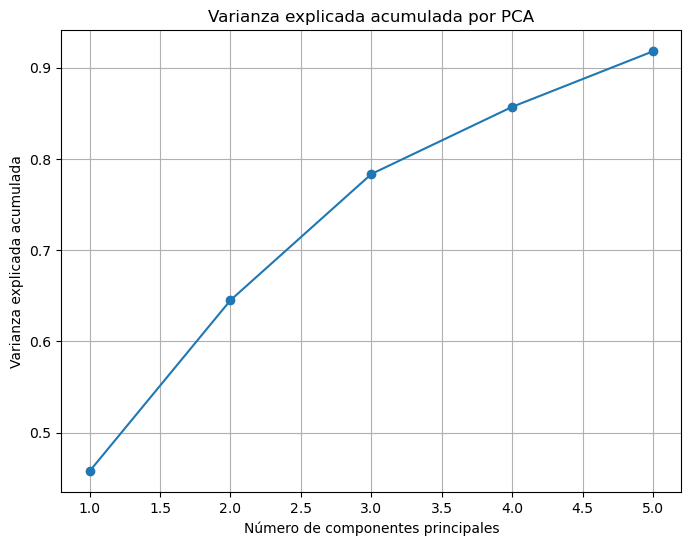

Varianza explicada por cada componente principal: [0.46074641 0.19369544 0.16668537 0.07081667 0.05442628]


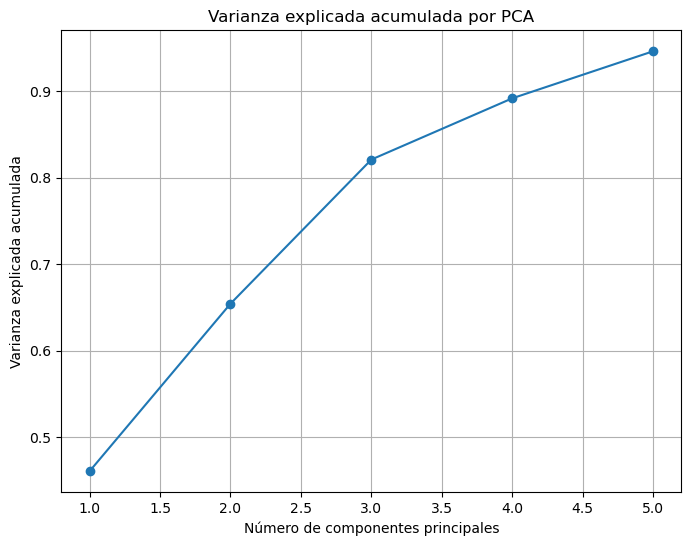

Varianza explicada por cada componente principal: [0.40064256 0.20060783 0.18461348 0.08902458 0.04885035]


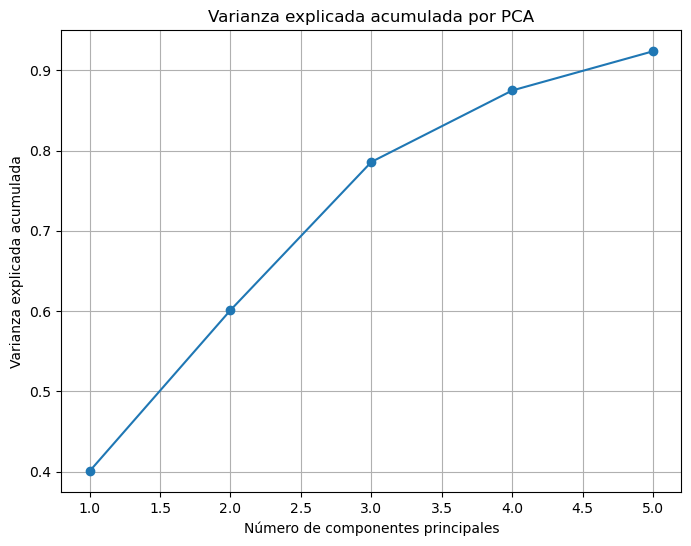

In [47]:
# Reducimos las características a 3 componentes principales
X_train_pca, pca_model = apply_pca_to_sequences(X_train_seq, n_components)
X_val_pca, _ = apply_pca_to_sequences(X_val_seq, n_components)
X_test_pca, _ = apply_pca_to_sequences(X_test_seq, n_components)

In [48]:
X_train_pca.shape

(2424, 72, 5)

In [49]:
# Paso 2: Verificar las nuevas dimensiones
print(f"Nuevas dimensiones de los datos de entrenamiento: {X_train_pca.shape}")
print(f"Nuevas dimensiones de los datos de validación: {X_val_pca.shape}")
print(f"Nuevas dimensiones de los datos de testeo: {X_test_pca.shape}")

Nuevas dimensiones de los datos de entrenamiento: (2424, 72, 5)
Nuevas dimensiones de los datos de validación: (553, 72, 5)
Nuevas dimensiones de los datos de testeo: (889, 72, 5)


In [50]:
n_steps = X_train_pca.shape[1]
n_features = X_train_pca.shape[2]
n_steps, n_features

(72, 5)

In [51]:
def forecast_battery_consumption2(test, pca ,seq_length, forecast_steps, future_steps, model, scaler_x, scaler_y):
    """
    This function forecasts battery consumption based on historical data using an LSTM model.

    Parameters:
    - test (pd.DataFrame): DataFrame containing test data with columns 'Rain meter', 'Soil moisture', 'Battery', and 'fecha'.
    - seq_length (int): Sequence length for creating input sequences.
    - forecast_steps (int): Number of steps ahead to forecast.
    - future_steps (int): Steps to shift for updating historical data.
    - model (Model): Trained LSTM model for prediction.
    - scaler_x (Scaler): Scaler for scaling the features.
    - scaler_y (Scaler): Scaler for scaling the target variable (battery).

    Returns:
    - historical_data (pd.DataFrame): Data with historical battery levels.
    - weather_forecast (pd.DataFrame): Forecasted battery levels.
    - forecast_data (pd.DataFrame): Actual battery levels for comparison.
    - metrics (dict): RMSE, MSE, and MAE metrics.
    """
    
    # Initial variables
    historical_data = test[:seq_length+1]  # First seq_length + 1 rows
    forecast_data = test[seq_length:seq_length+forecast_steps]  # Rows to be forecasted
    weather_forecast = forecast_data.drop(columns=['battery'])  # Exclude battery initially
    weather_forecast['battery'] = np.nan  # Add placeholder column for predictions
    updated_historical_data = historical_data.copy()  # Initialize with historical data

    # Loop to generate predictions
    for steps in range(0, forecast_steps, future_steps):
        # Normalize historical data
        X_hist, y_hist = normalise_data(
            scaler_x,
            updated_historical_data.drop(columns=['fecha']),
            scaler_y,
            updated_historical_data['battery']
        )
        
        #PCA
        X_hist_pca = pca_model.fit_transform(X_hist)
        
        # Create sequences
        X_hist_seq, y_hist_seq = create_sequences(X_hist_pca, y_hist.values, seq_length)

        # Make predictions
        next_battery_pred = model.predict(X_hist_seq)
        
        clear_output(wait=True)

        # Inverse normalization of predictions
        next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred).flatten()

        # Update the forecast data with predicted values
        weather_forecast.loc[weather_forecast.index[steps:steps+future_steps], 'battery'] = next_battery_pred_inv[:future_steps]

        # Update historical data for the next iteration
        updated_historical_data = pd.concat(
            [updated_historical_data[future_steps:], weather_forecast.iloc[steps:steps+future_steps]],
            ignore_index=True
        )

    # Plot actual vs predicted with dates
    plt.figure(figsize=(20, 6))

    plt.plot(pd.to_datetime(historical_data['fecha']), historical_data['battery'], label='Historic')
    plt.plot(pd.to_datetime(weather_forecast['fecha']), weather_forecast['battery'], label='Forecast', marker=".")
    plt.plot(pd.to_datetime(forecast_data['fecha']), forecast_data['battery'], label='Real', marker=".")
    plt.title('Actual vs Forecasted Battery Consumption')
    plt.xlabel('Time')
    plt.ylabel('Battery Consumption')
    plt.legend()
    plt.grid()
    plt.show()

    print('RMSE: ', root_mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MSE:  ', mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MAE:  ', mean_absolute_error(forecast_data['battery'], weather_forecast['battery']))

    return historical_data, weather_forecast, forecast_data, updated_historical_data

### Modelo GRU Sofisticado

In [52]:
# Crear el modelo
gru_models = Sequential()
# Capa GRU 1 (con 50 unidades)
gru_models.add(GRU(50, return_sequences=True, input_shape=(n_steps, n_features)))
# Dropout para regularización
gru_models.add(Dropout(0.2))
# Capa GRU 2 (con 50 unidades)
gru_models.add(GRU(50))
# Dropout para regularización
gru_models.add(Dropout(0.2))
# Capa densa 1 (con 64 neuronas)
gru_models.add(Dense(64, activation='relu'))
# Capa densa 2 (con 32 neuronas)
gru_models.add(Dense(32, activation='relu'))
# Capa de salida (con 1 neurona para la predicción final)
gru_models.add(Dense(1))
gru_models.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
gru_models.summary()

2024-12-01 09:36:36.197422: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2024-12-01 09:36:36.197464: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: hp-elite
2024-12-01 09:36:36.197481: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: hp-elite
2024-12-01 09:36:36.197567: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 520.61.5
2024-12-01 09:36:36.197597: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 520.61.5
2024-12-01 09:36:36.197604: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:310] kernel version seems to match DSO: 520.61.5
2024-12-01 09:36:36.197867: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Lib

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 72, 50)            8550      
                                                                 
 dropout (Dropout)           (None, 72, 50)            0         
                                                                 
 gru_1 (GRU)                 (None, 50)                15300     
                                                                 
 dropout_1 (Dropout)         (None, 50)                0         
                                                                 
 dense (Dense)               (None, 64)                3264      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 3

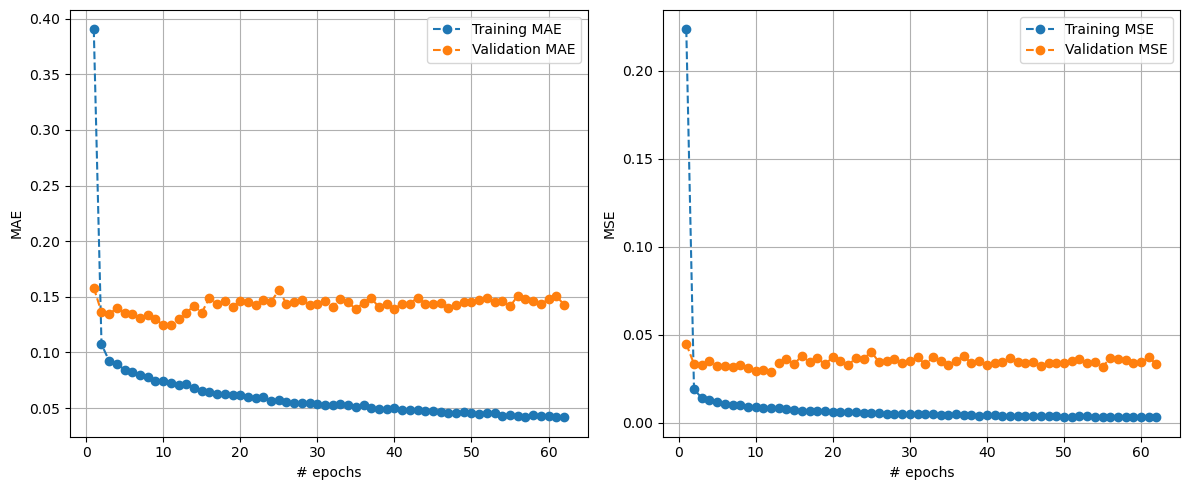

34/34 [==============================] - 3s 82ms/step - loss: 0.0031 - mean_absolute_error: 0.0417 - val_loss: 0.0333 - val_mean_absolute_error: 0.1430


In [53]:
gru_models.fit(X_train_pca,
                    y_train_seq,
                    epochs=300,
                    batch_size=batch_size,
                    validation_data=(X_val_pca, y_val_seq),
                    callbacks=[
                    PlotLearning(),
                    EarlyStopping(monitor='val_loss', patience=50)])

In [54]:
# Evaluar en el conjunto de testeo
loss_model_gru = gru_models.evaluate(X_test_pca, y_test_seq)
print(f"Pérdida final en el conjunto de testeo: {loss_model_gru}")

28/28 [==============================] - 0s 17ms/step - loss: 0.0333 - mean_absolute_error: 0.1422
Pérdida final en el conjunto de testeo: [0.0332578644156456, 0.14219121634960175]


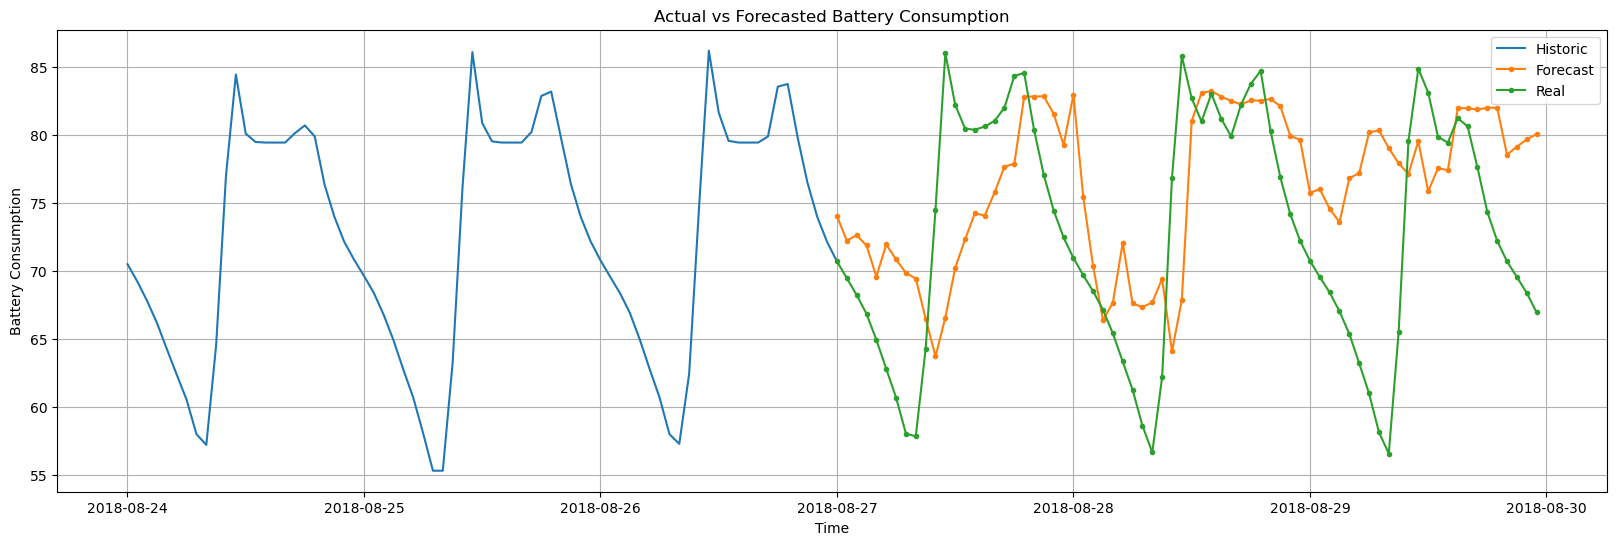

RMSE:  8.719110332852575
MSE:   76.02288499645653
MAE:   7.044778575897218


(                 fecha  temperature  pressure  battery  air_humidity  \
 0  2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1  2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2  2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3  2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4  2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                 ...          ...       ...      ...           ...   
 68 2018-08-26 20:00:00      27.3125  984.4450  79.8525       61.2500   
 69 2018-08-26 21:00:00      24.8025  984.9600  76.5075       67.5050   
 70 2018-08-26 22:00:00      23.7150  985.4000  73.9700       69.4225   
 71 2018-08-26 23:00:00      22.4675  985.5450  72.1250       69.8875   
 72 2018-08-27 00:00:00      21.5750  985.6575  70.6925       71.6725   
 
     wind_speed  irradiancia  minutos_dia  hora  
 0       1.2050          0.0        807.0     0  
 1       1.2050       

In [55]:
forecast_battery_consumption2(test=test_dataset, pca=pca_model, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=gru_models, scaler_x=scaler_x, scaler_y=scaler_y)

In [56]:
# Define model
lstm_double_model = Sequential()
lstm_double_model.add(LSTM(50, return_sequences=True, input_shape=(n_steps, n_features)))
lstm_double_model.add(LSTM(50))
lstm_double_model.add(Dense(1, activation="sigmoid"))
lstm_double_model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
lstm_double_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 72, 50)            11200     
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 31,451
Trainable params: 31,451
Non-trainable params: 0
_________________________________________________________________


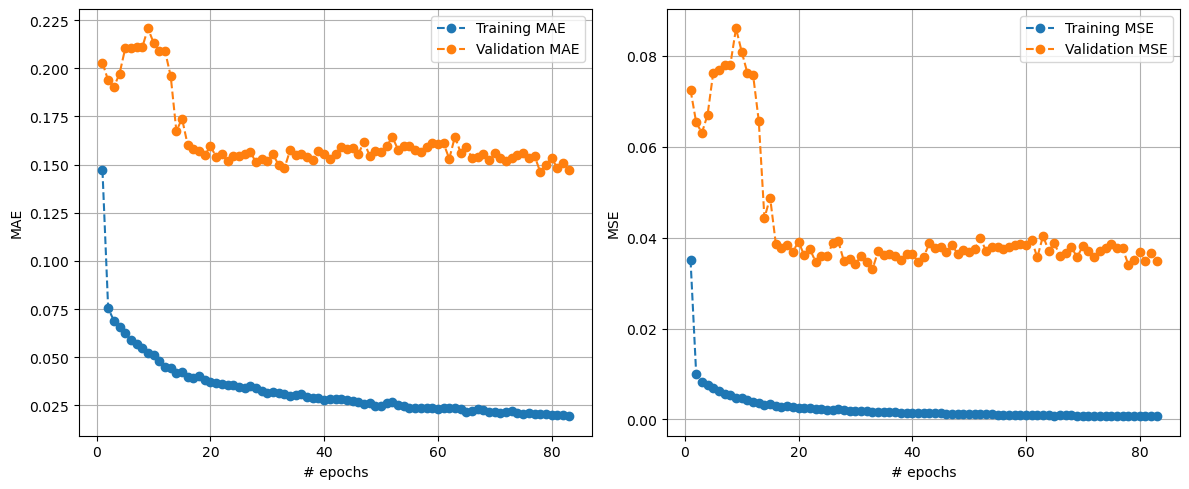

34/34 [==============================] - 3s 97ms/step - loss: 6.9504e-04 - mean_absolute_error: 0.0193 - val_loss: 0.0349 - val_mean_absolute_error: 0.1471


In [57]:
lstm_double_model.fit(
      X_train_pca,
      y_train_seq,
      epochs=300,
      batch_size=batch_size,
      validation_data=(X_val_pca, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

In [58]:
# Evaluar en el conjunto de testeo
loss_model3 = lstm_double_model.evaluate(X_test_pca, y_test_seq)
print(f"Pérdida final en el conjunto de testeo: {loss_model3}")

28/28 [==============================] - 1s 22ms/step - loss: 0.0521 - mean_absolute_error: 0.1703
Pérdida final en el conjunto de testeo: [0.05208417773246765, 0.17026333510875702]


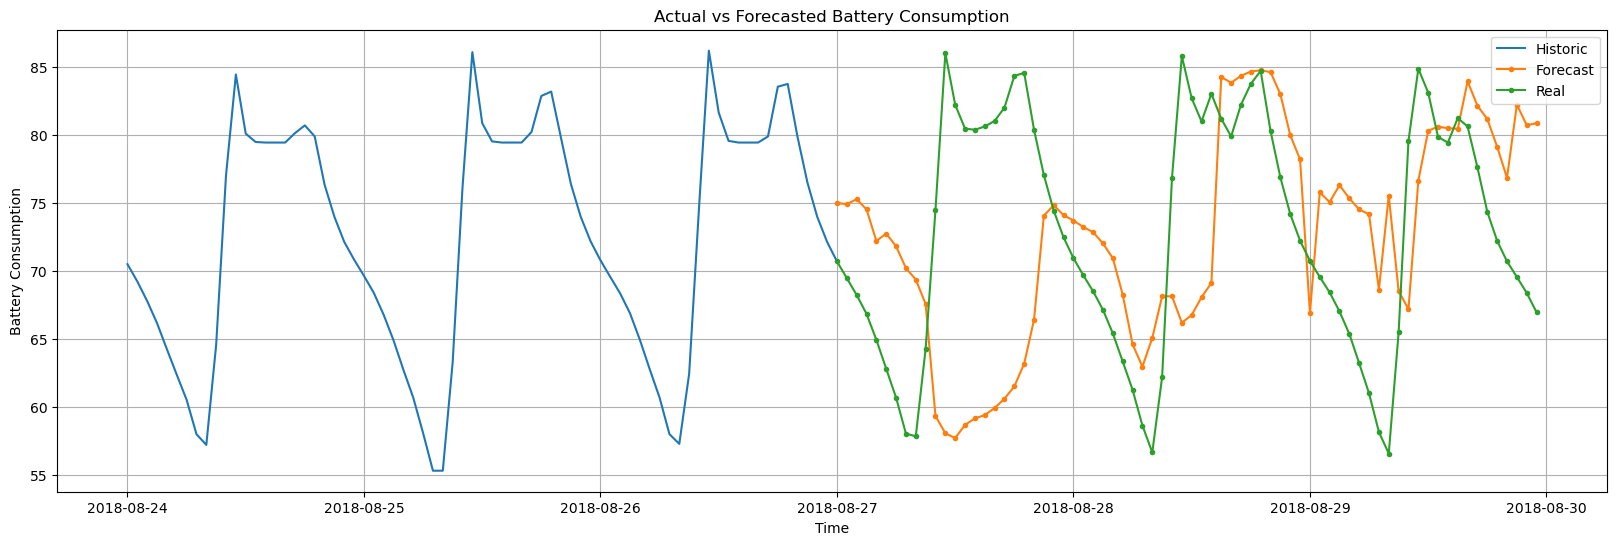

RMSE:  11.346391343804084
MSE:   128.74059652675226
MAE:   9.09792563756307


(                 fecha  temperature  pressure  battery  air_humidity  \
 0  2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1  2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2  2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3  2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4  2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                 ...          ...       ...      ...           ...   
 68 2018-08-26 20:00:00      27.3125  984.4450  79.8525       61.2500   
 69 2018-08-26 21:00:00      24.8025  984.9600  76.5075       67.5050   
 70 2018-08-26 22:00:00      23.7150  985.4000  73.9700       69.4225   
 71 2018-08-26 23:00:00      22.4675  985.5450  72.1250       69.8875   
 72 2018-08-27 00:00:00      21.5750  985.6575  70.6925       71.6725   
 
     wind_speed  irradiancia  minutos_dia  hora  
 0       1.2050          0.0        807.0     0  
 1       1.2050       

In [59]:
forecast_battery_consumption2(test=test_dataset, pca=pca_model, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=lstm_double_model, scaler_x=scaler_x, scaler_y=scaler_y)